In [56]:
import pandas as pd

In [57]:
df = pd.read_csv("../data/delivery_data.csv")

In [58]:
df.head()

,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333


In [59]:
df.shape

(10000, 17)

In [60]:
df.columns

Index(['Traffic_Level', 'ID', 'Delivery_person_ID', 'weather_description',
       'Type_of_order', 'Type_of_vehicle', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'temperature', 'humidity',
       'precipitation', 'Distance (km)', 'TARGET'],
      dtype='str')

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Traffic_Level                9085 non-null   str    
 1   ID                           10000 non-null  str    
 2   Delivery_person_ID           10000 non-null  str    
 3   weather_description          9995 non-null   str    
 4   Type_of_order                10000 non-null  str    
 5   Type_of_vehicle              10000 non-null  str    
 6   Delivery_person_Age          10000 non-null  int64  
 7   Delivery_person_Ratings      10000 non-null  float64
 8   Restaurant_latitude          10000 non-null  str    
 9   Restaurant_longitude         10000 non-null  str    
 10  Delivery_location_latitude   10000 non-null  str    
 11  Delivery_location_longitude  10000 non-null  str    
 12  temperature                  9995 non-null   float64
 13  humidity                    

In [62]:
df.isnull().sum()

Traffic_Level                  915
ID                               0
Delivery_person_ID               0
weather_description              5
Type_of_order                    0
Type_of_vehicle                  0
Delivery_person_Age              0
Delivery_person_Ratings          0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
temperature                      5
humidity                         5
precipitation                    5
Distance (km)                  920
TARGET                         541
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(0)

In [64]:
df["TARGET"].describe()

count        9459
unique       3370
top       #VALUE!
freq          419
Name: TARGET, dtype: object

In [65]:
df["TARGET"].value_counts().head(20)

TARGET
#VALUE!          419
3.336.666.667     12
34.8              11
2.988.333.333     11
3.053.333.333     11
3.416.666.667     10
35.3              10
3.281.666.667     10
2.921.666.667     10
3.121.666.667     10
4.663.333.333      9
3.478.333.333      9
41                 9
3.728.333.333      9
1.858.333.333      9
20.3               9
2.383.333.333      9
23.6               9
3.238.333.333      9
3.636.666.667      8
Name: count, dtype: int64

In [66]:
df["TARGET"].unique()[:20]

<ArrowStringArray>
[        '43.45', '3.816.666.667', '3.636.666.667',         '49.45',
 '5.248.333.333', '3.461.666.667', '4.416.666.667', '5.438.333.333',
 '4.746.666.667', '4.728.333.333',         '46.25', '4.061.666.667',
 '4.418.333.333',         '46.45',         '50.35', '4.971.666.667',
          '42.3', '4.548.333.333', '4.558.333.333', '4.021.666.667']
Length: 20, dtype: str

In [67]:
df["TARGET"].astype(str).str.count(r"\.").value_counts()

TARGET
3.0    6039
1.0    2850
0.0     570
Name: count, dtype: int64

In [68]:
df.loc[
    df["TARGET"].astype(str).str.count(r"\.") > 1,
    "TARGET"
].head(20)

1     3.816.666.667
2     3.636.666.667
4     5.248.333.333
5     3.461.666.667
6     4.416.666.667
7     5.438.333.333
8     4.746.666.667
9     4.728.333.333
11    4.061.666.667
12    4.418.333.333
15    4.971.666.667
17    4.548.333.333
18    4.558.333.333
19    3.636.666.667
20    4.021.666.667
21    4.791.666.667
23    4.681.666.667
24    5.281.666.667
25    5.231.666.667
28    4.573.333.333
Name: TARGET, dtype: str

In [69]:
df.loc[
    df["TARGET"].astype(str).str.count(r"\.") > 1,
    "TARGET"
].sample(20, random_state=42).tolist()

['6.136.666.667',
 '4.541.666.667',
 '1.567.166.667',
 '1.793.333.333',
 '4.681.666.667',
 '2.388.333.333',
 '1.896.666.667',
 '2.991.666.667',
 '3.388.333.333',
 '4.333.333.333',
 '3.603.333.333',
 '5.303.333.333',
 '5.068.333.333',
 '5.136.666.667',
 '2.611.666.667',
 '4.196.666.667',
 '2.576.666.667',
 '6.226.666.667',
 '1.403.333.333',
 '4.421.666.667']

In [70]:
test_values = [
    "6.136.666.667",
    "4.541.666.667",
    "1.567.166.667",
    "3.816.666.667"
]

for value in test_values:
    digits = value.replace(".", "")
    print(value, "→", digits)

6.136.666.667 → 6136666667
4.541.666.667 → 4541666667
1.567.166.667 → 1567166667
3.816.666.667 → 3816666667


In [71]:
import numpy as np

def clean_target(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    # Invalid target
    if value == "#VALUE!":
        return np.nan
    
    # Normal value: 43.45, 34.8, 41 etc.
    if value.count(".") <= 1:
        return float(value)
    
    # Malformed value: 3.816.666.667
    digits = value.replace(".", "")
    
    # Put decimal before last 8 digits
    return float(digits[:-8] + "." + digits[-8:])


df["TARGET"] = df["TARGET"].apply(clean_target)

In [72]:
df["TARGET"].describe()

count    9040.000000
mean       38.007474
std        16.442651
min         5.800000
25%        25.866667
50%        36.183333
75%        47.900000
max       157.750000
Name: TARGET, dtype: float64

In [73]:
df["TARGET"].isnull().sum()

np.int64(960)

In [74]:
df["TARGET"].dtype

dtype('float64')

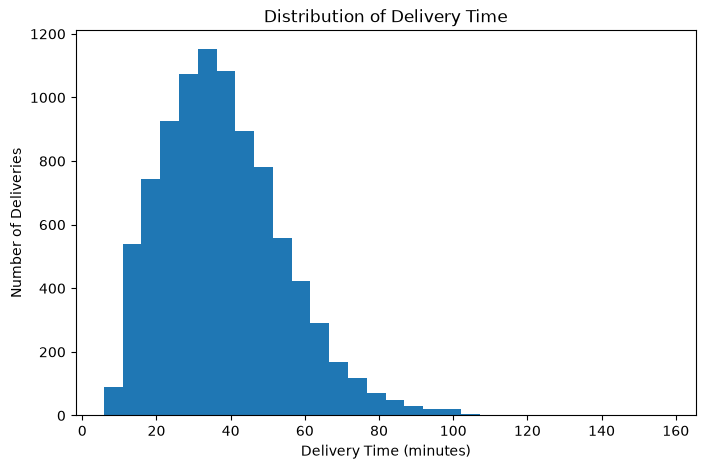

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["TARGET"].dropna(), bins=30)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Deliveries")
plt.title("Distribution of Delivery Time")
plt.show()

In [76]:
categorical_cols = [
    "Traffic_Level",
    "weather_description",
    "Type_of_order",
    "Type_of_vehicle"
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 Traffic_Level
Traffic_Level
High         2736
Moderate     2219
Very High    1772
Low          1726
NaN           915
Very Low      632
Name: count, dtype: int64

 weather_description
weather_description
clear sky           3260
haze                2406
mist                1751
broken clouds        721
light rain           536
smoke                501
scattered clouds     422
overcast clouds      308
fog                   49
few clouds            40
NaN                    5
moderate rain          1
Name: count, dtype: int64

 Type_of_order
Type_of_order
Snack     2551
Meal      2530
Drinks    2507
Buffet    2412
Name: count, dtype: int64

 Type_of_vehicle
Type_of_vehicle
motorcycle          5862
scooter             3304
electric_scooter     814
bicycle               20
Name: count, dtype: int64


In [77]:
numeric_cols = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "temperature",
    "humidity",
    "precipitation",
    "Distance (km)"
]

df[numeric_cols].describe()

,Delivery_person_Age,Delivery_person_Ratings,temperature,humidity,precipitation,Distance (km)
count,10000.000000,10000.000000,9995.000000,9995.000000,9995.000000,9080.000000
mean,29.522000,4.629370,22.936907,66.164882,0.016233,14.292747
std,5.700348,0.322941,3.379448,15.602939,0.074911,8.376254
min,15.000000,1.000000,6.770000,27.000000,0.000000,1.550000
25%,25.000000,4.500000,20.140000,54.000000,0.000000,7.620000
50%,29.000000,4.700000,23.000000,67.000000,0.000000,13.400000
75%,34.000000,4.800000,25.980000,81.000000,0.000000,19.610000
max,50.000000,6.000000,29.050000,94.000000,1.460000,59.840000


In [78]:
df[numeric_cols].isnull().sum()

Delivery_person_Age          0
Delivery_person_Ratings      0
temperature                  5
humidity                     5
precipitation                5
Distance (km)              920
dtype: int64

In [79]:
coordinate_cols = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]

for col in coordinate_cols:
    print("\n", col)
    print(df[col].head(10).tolist())


 Restaurant_latitude
['12.972.793', '23.369.746', '30.327.968', '1.856.245', '17.426.228', '19.221.315', '21.160.522', '18.563.934', '1.855.144', '12.972.532']

 Restaurant_longitude
['80.249.982', '8.533.982', '78.046.106', '73.916.619', '78.407.495', '72.862.381', '72.771.477', '73.915.367', '73.804.855', '77.608.179']

 Delivery_location_latitude
['13.012.793', '23.479.746', '30.397.968', '1.865.245', '17.496.228', '19.261.315', '21.250.522', '18.693.935', '1.862.144', '13.042.532']

 Delivery_location_longitude
['80.289.982', '8.544.982', '78.116.106', '74.006.619', '78.477.495', '72.902.381', '72.861.477', '74.045.367', '73.874.855', '77.678.179']


In [80]:
test_coords = [
    "12.972.793",
    "23.369.746",
    "30.327.968",
    "1.856.245",
    "80.249.982"
]

for value in test_coords:
    parts = value.split(".")
    cleaned = float(parts[0] + "." + parts[1] + parts[2])
    print(value, "→", cleaned)

12.972.793 → 12.972793
23.369.746 → 23.369746
30.327.968 → 30.327968
1.856.245 → 1.856245
80.249.982 → 80.249982


In [81]:
coordinate_cols = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]

def clean_coordinate(value, coordinate_type):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    max_valid = 90 if coordinate_type == "latitude" else 180

    # Case 1: already a valid normal coordinate
    if value.count(".") == 1:
        number = float(value)

        if -max_valid <= number <= max_valid:
            return number

        # Case 2: malformed value such as 191.813 → 19.1813
        sign = ""
        if value.startswith("-"):
            sign = "-"
            value = value[1:]

        digits = value.replace(".", "")

        return float(
            sign + digits[:2] + "." + digits[2:]
        )

    # Case 3: malformed value such as 12.972.793 → 12.972793
    if value.count(".") == 2:
        parts = value.split(".")

        return float(
            parts[0] + "." + parts[1] + parts[2]
        )

    # Case 4: already numeric / unexpected format
    return float(value)


for col in coordinate_cols:
    coordinate_type = "latitude" if "latitude" in col else "longitude"

    df[col] = df[col].apply(
        lambda x: clean_coordinate(x, coordinate_type)
    )

print("Coordinate cleaning completed successfully.")

Coordinate cleaning completed successfully.


In [82]:
for col in coordinate_cols:
    print("\n", col)
    print(
        df[col].astype(str)
        .loc[df[col].astype(str).str.count(r"\.") != 2]
        .head(20)
    )


 Restaurant_latitude
0     12.972793
1     23.369746
2     30.327968
3      1.856245
4     17.426228
5     19.221315
6     21.160522
7     18.563934
8      1.855144
9     12.972532
10    19.121999
11    19.221315
12    12.970324
13    13.064181
14    11.003681
15     1.096185
16    21.183434
17    12.935662
18    17.431477
19    17.411028
Name: Restaurant_latitude, dtype: str

 Restaurant_longitude
0     80.249982
1      8.533982
2     78.046106
3     73.916619
4     78.407495
5     72.862381
6     72.771477
7     73.915367
8     73.804855
9     77.608179
10    72.908493
11    72.862381
12    77.645748
13    80.236442
14    76.975525
15    76.971082
16    72.814492
17     7.761413
18     7.840035
19    78.329645
Name: Restaurant_longitude, dtype: str

 Delivery_location_latitude
0     13.012793
1     23.479746
2     30.397968
3      1.865245
4     17.496228
5     19.261315
6     21.250522
7     18.693935
8      1.862144
9     13.042532
10    19.201999
11    19.281315
12    13.030324
1

In [83]:
df = pd.read_csv("../data/delivery_data.csv")

In [84]:
coordinate_cols = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]

for col in coordinate_cols:
    print("\n", col)
    print(df[col].head(10).tolist())


 Restaurant_latitude
['12.972.793', '23.369.746', '30.327.968', '1.856.245', '17.426.228', '19.221.315', '21.160.522', '18.563.934', '1.855.144', '12.972.532']

 Restaurant_longitude
['80.249.982', '8.533.982', '78.046.106', '73.916.619', '78.407.495', '72.862.381', '72.771.477', '73.915.367', '73.804.855', '77.608.179']

 Delivery_location_latitude
['13.012.793', '23.479.746', '30.397.968', '1.865.245', '17.496.228', '19.261.315', '21.250.522', '18.693.935', '1.862.144', '13.042.532']

 Delivery_location_longitude
['80.289.982', '8.544.982', '78.116.106', '74.006.619', '78.477.495', '72.902.381', '72.861.477', '74.045.367', '73.874.855', '77.678.179']


In [85]:
for col in coordinate_cols:
    print("\n", col)
    print(df[col].astype(str).str.count(r"\.").value_counts())


 Restaurant_latitude
Restaurant_latitude
2    9062
0     801
1     137
Name: count, dtype: int64

 Restaurant_longitude
Restaurant_longitude
2    9001
0     801
1     198
Name: count, dtype: int64

 Delivery_location_latitude
Delivery_location_latitude
2    9062
1     938
Name: count, dtype: int64

 Delivery_location_longitude
Delivery_location_longitude
2    9001
1     999
Name: count, dtype: int64


In [86]:
def clean_coordinate(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Already normal numeric format
    if value.count(".") <= 1:
        return float(value)

    # Format like 12.972.793 → 12.972793
    parts = value.split(".")
    return float(parts[0] + "." + "".join(parts[1:]))

In [87]:
for col in coordinate_cols:
    df[col] = df[col].apply(clean_coordinate)

In [88]:
df[coordinate_cols].head()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
0,12.972793,80.249982,13.012793,80.289982
1,23.369746,8.533982,23.479746,8.544982
2,30.327968,78.046106,30.397968,78.116106
3,1.856245,73.916619,1.865245,74.006619
4,17.426228,78.407495,17.496228,78.477495


In [89]:
df[coordinate_cols].dtypes

Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
dtype: object

In [90]:
for col in coordinate_cols:
    print("\n", col)
    print("Min:", df[col].min())
    print("Max:", df[col].max())


 Restaurant_latitude
Min: -155.696
Max: 225.491

 Restaurant_longitude
Min: -88.352885
Max: 853.329

 Delivery_location_latitude
Min: 0.01
Max: 226.291

 Delivery_location_longitude
Min: 0.01
Max: 854.629


In [91]:
print("Invalid restaurant latitude:",
      ((df["Restaurant_latitude"] < -90) |
       (df["Restaurant_latitude"] > 90)).sum())

print("Invalid restaurant longitude:",
      ((df["Restaurant_longitude"] < -180) |
       (df["Restaurant_longitude"] > 180)).sum())

print("Invalid delivery latitude:",
      ((df["Delivery_location_latitude"] < -90) |
       (df["Delivery_location_latitude"] > 90)).sum())

print("Invalid delivery longitude:",
      ((df["Delivery_location_longitude"] < -180) |
       (df["Delivery_location_longitude"] > 180)).sum())

Invalid restaurant latitude: 74
Invalid restaurant longitude: 168
Invalid delivery latitude: 74
Invalid delivery longitude: 168


In [92]:
invalid_lat = df[
    (df["Restaurant_latitude"] < -90) |
    (df["Restaurant_latitude"] > 90)
]["Restaurant_latitude"]

print("Restaurant invalid latitude:")
print(invalid_lat.value_counts())

Restaurant invalid latitude:
Restaurant_latitude
 191.093    36
 191.813    23
 225.491     8
 155.696     5
-155.696     2
Name: count, dtype: int64


In [93]:
invalid_lon = df[
    (df["Restaurant_longitude"] < -180) |
    (df["Restaurant_longitude"] > 180)
]["Restaurant_longitude"]

print("\nRestaurant invalid longitude:")
print(invalid_lon.value_counts())


Restaurant invalid longitude:
Restaurant_longitude
758.023    40
776.784    38
853.329    36
853.172    28
758.934    23
803.481     3
Name: count, dtype: int64


In [94]:
print(
    df.loc[
        (df["Restaurant_latitude"] < -90) |
        (df["Restaurant_latitude"] > 90) |
        (df["Restaurant_longitude"] < -180) |
        (df["Restaurant_longitude"] > 180),
        ["Restaurant_latitude", "Restaurant_longitude"]
    ].head(20)
)

     Restaurant_latitude  Restaurant_longitude
66             26.846156            758.023000
74              2.274806            758.934000
98             23.354422            853.329000
138           191.813000             72.836191
147            26.846156            758.023000
185            23.354422            853.329000
289            26.846156            758.023000
301           191.093000             72.825451
325           191.813000             72.836191
372           191.093000             72.825451
395           191.093000             72.825451
428            23.333017            853.172000
442            23.354422            853.329000
443            23.354422            853.329000
460            23.333017            853.172000
515            26.846156            758.023000
531            23.354422            853.329000
535            26.846156            758.023000
582            23.333017            853.172000
600           191.093000             72.825451


In [95]:
raw_df = pd.read_csv("../data/delivery_data.csv")

print(
    raw_df.loc[
        raw_df["Restaurant_latitude"].astype(str).isin(
            ["191.813", "191.093", "225.491", "155.696", "-155.696"]
        ),
        [
            "Restaurant_latitude",
            "Restaurant_longitude",
            "Delivery_location_latitude",
            "Delivery_location_longitude"
        ]
    ].head(20)
)

     Restaurant_latitude Restaurant_longitude Delivery_location_latitude  \
138              191.813           72.836.191                    192.413   
301              191.093           72.825.451                    191.793   
325              191.813           72.836.191                    192.313   
372              191.093           72.825.451                    191.793   
395              191.093           72.825.451                    191.693   
600              191.093           72.825.451                    191.493   
626              191.093           72.825.451                    191.693   
702              191.093           72.825.451                    191.693   
1092             191.093           72.825.451                    191.593   
1137             191.813           72.836.191                    192.413   
1260             225.491           88.400.467                    226.291   
1691             191.813           72.836.191                    192.413   
1716        

In [96]:
print(
    raw_df.loc[
        raw_df["Restaurant_longitude"].astype(str).isin(
            ["758.023", "776.784", "853.329", "853.172", "758.934", "803.481"]
        ),
        [
            "Restaurant_latitude",
            "Restaurant_longitude",
            "Delivery_location_latitude",
            "Delivery_location_longitude"
        ]
    ].head(20)
)

    Restaurant_latitude Restaurant_longitude Delivery_location_latitude  \
66           26.846.156              758.023                 26.926.156   
74            2.274.806              758.934                  2.283.806   
98           23.354.422              853.329                 23.484.422   
147          26.846.156              758.023                 26.956.156   
185          23.354.422              853.329                 23.424.422   
289          26.846.156              758.023                 26.956.156   
428          23.333.017              853.172                 23.403.017   
442          23.354.422              853.329                 23.444.422   
443          23.354.422              853.329                 23.484.422   
460          23.333.017              853.172                 23.393.017   
515          26.846.156              758.023                 26.926.156   
531          23.354.422              853.329                 23.484.422   
535          26.846.156  

In [97]:
df = pd.read_csv("../data/delivery_data.csv")

In [98]:
def clean_coordinate(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Normal 2-dot format:
    # 12.972.793 → 12.972793
    if value.count(".") == 2:
        parts = value.split(".")
        return float(parts[0] + "." + parts[1] + parts[2])

    # Normal coordinate:
    # 12.3085, 2.274806 etc.
    if value.count(".") == 1:
        integer_part = value.split(".")[0]
        
        # If already a valid coordinate, keep it
        if abs(float(value)) <= 180:
            return float(value)
        
        # Corrupted format:
        # 191.813 → 19.1813
        # 758.023 → 75.8023
        sign = ""
        if value.startswith("-"):
            sign = "-"
            value = value[1:]
        
        digits = value.replace(".", "")
        return float(sign + digits[:2] + "." + digits[2:])

    # No decimal point
    return float(value)

In [99]:
coordinate_cols = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]

for col in coordinate_cols:
    df[col] = df[col].apply(clean_coordinate)

In [100]:
df[coordinate_cols].head()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
0,12.972793,80.249982,13.012793,80.289982
1,23.369746,8.533982,23.479746,8.544982
2,30.327968,78.046106,30.397968,78.116106
3,1.856245,73.916619,1.865245,74.006619
4,17.426228,78.407495,17.496228,78.477495


In [101]:
df[coordinate_cols].dtypes

Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
dtype: object

In [102]:
print("Invalid restaurant latitude:",
      ((df["Restaurant_latitude"] < -90) |
       (df["Restaurant_latitude"] > 90)).sum())

print("Invalid restaurant longitude:",
      ((df["Restaurant_longitude"] < -180) |
       (df["Restaurant_longitude"] > 180)).sum())

print("Invalid delivery latitude:",
      ((df["Delivery_location_latitude"] < -90) |
       (df["Delivery_location_latitude"] > 90)).sum())

print("Invalid delivery longitude:",
      ((df["Delivery_location_longitude"] < -180) |
       (df["Delivery_location_longitude"] > 180)).sum())

Invalid restaurant latitude: 7
Invalid restaurant longitude: 0
Invalid delivery latitude: 7
Invalid delivery longitude: 0


In [103]:
print(df.loc[
    (df["Restaurant_latitude"] < -90) |
    (df["Restaurant_latitude"] > 90),
    "Restaurant_latitude"
].value_counts())

print(df.loc[
    (df["Delivery_location_latitude"] < -90) |
    (df["Delivery_location_latitude"] > 90),
    "Delivery_location_latitude"
].value_counts())

Restaurant_latitude
 155.696    5
-155.696    2
Name: count, dtype: int64
Delivery_location_latitude
156.296    2
155.796    1
155.896    1
156.096    1
156.196    1
156.596    1
Name: count, dtype: int64


In [104]:
def fix_latitude(value):
    if pd.isna(value):
        return np.nan

    if abs(value) > 90:
        sign = "-" if value < 0 else ""
        digits = str(abs(value)).replace(".", "")
        return float(sign + digits[:2] + "." + digits[2:])

    return value


df["Restaurant_latitude"] = df["Restaurant_latitude"].apply(fix_latitude)
df["Delivery_location_latitude"] = df["Delivery_location_latitude"].apply(fix_latitude)

In [105]:
print("Invalid restaurant latitude:",
      ((df["Restaurant_latitude"] < -90) |
       (df["Restaurant_latitude"] > 90)).sum())

print("Invalid restaurant longitude:",
      ((df["Restaurant_longitude"] < -180) |
       (df["Restaurant_longitude"] > 180)).sum())

print("Invalid delivery latitude:",
      ((df["Delivery_location_latitude"] < -90) |
       (df["Delivery_location_latitude"] > 90)).sum())

print("Invalid delivery longitude:",
      ((df["Delivery_location_longitude"] < -180) |
       (df["Delivery_location_longitude"] > 180)).sum())

Invalid restaurant latitude: 0
Invalid restaurant longitude: 0
Invalid delivery latitude: 0
Invalid delivery longitude: 0


In [106]:
def clean_target(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Invalid text
    if value == "#VALUE!":
        return np.nan

    # Normal number
    if value.count(".") <= 1:
        return float(value)

    # Example:
    # 3.816.666.667 → 38.16666667
    parts = value.split(".")
    return float(parts[0] + "." + "".join(parts[1:]))


df["TARGET"] = df["TARGET"].apply(clean_target)

In [107]:
print(df["TARGET"].dtype)
print(df["TARGET"].isna().sum())
print(df["TARGET"].describe())

float64
960
count    9040.000000
mean       14.953246
std        18.502133
min         1.002833
25%         3.156667
50%         4.822500
75%        24.962500
max       157.750000
Name: TARGET, dtype: float64


In [108]:
print(df["TARGET"].head(20).to_list())

[43.45, 3.816666667, 3.636666667, 49.45, 5.248333333, 3.461666667, 4.416666667, 5.438333333, 4.746666667, 4.728333333, 46.25, 4.061666667, 4.418333333, 46.45, 50.35, 4.971666667, 42.3, 4.548333333, 4.558333333, 3.636666667]


In [109]:
print(df["TARGET"].sort_values().head(20).to_list())
print(df["TARGET"].sort_values(ascending=False).head(20).to_list())

[1.002833333, 1.004833333, 1.005833333, 1.006666667, 1.011333333, 1.011333333, 1.012333333, 1.018333333, 1.018333333, 1.023333333, 1.023333333, 1.026666667, 1.026666667, 1.026666667, 1.031666667, 1.038333333, 1.038333333, 1.038333333, 1.046666667, 1.051666667]
[157.75, 140.0, 107.3, 105.95, 104.45, 104.05, 103.5, 101.0, 100.65, 100.25, 99.85, 97.8, 96.05, 94.6, 93.3, 92.8, 92.35, 91.5, 91.2, 91.15]


In [110]:
df = pd.read_csv("../data/delivery_data.csv")

In [111]:
def clean_target(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "#VALUE!":
        return np.nan

    if value.count(".") <= 1:
        return float(value)

    # 3.816.666.667 → 38.166666667
    parts = value.split(".")
    return float(parts[0] + parts[1] + "." + "".join(parts[2:]))


df["TARGET"] = df["TARGET"].apply(clean_target)

In [112]:
print(df["TARGET"].describe())
print("Missing TARGET:", df["TARGET"].isna().sum())

count    9040.000000
mean     2573.972601
std      2232.020483
min         5.800000
25%        47.637500
50%      2636.666667
75%      4191.666667
max      9983.333333
Name: TARGET, dtype: float64
Missing TARGET: 960


In [113]:
def clean_target(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Invalid value
    if value == "#VALUE!":
        return np.nan

    # Normal value, e.g. 43.45
    if value.count(".") <= 1:
        return float(value)

    # Corrupted value:
    # 3.816.666.667 → 38.16666667
    digits = value.replace(".", "")

    return float(digits[:2] + "." + digits[2:])


df["TARGET"] = df["TARGET"].apply(clean_target)

In [114]:
print(df["TARGET"].describe())
print("Missing TARGET:", df["TARGET"].isna().sum())

count    9040.000000
mean     2573.972601
std      2232.020483
min         5.800000
25%        47.637500
50%      2636.666667
75%      4191.666667
max      9983.333333
Name: TARGET, dtype: float64
Missing TARGET: 960


In [115]:
raw_target = pd.read_csv("../data/delivery_data.csv")["TARGET"]

print(raw_target[raw_target.astype(str).str.count(r"\.") == 3].head(20).to_list())

['3.816.666.667', '3.636.666.667', '5.248.333.333', '3.461.666.667', '4.416.666.667', '5.438.333.333', '4.746.666.667', '4.728.333.333', '4.061.666.667', '4.418.333.333', '4.971.666.667', '4.548.333.333', '4.558.333.333', '3.636.666.667', '4.021.666.667', '4.791.666.667', '4.681.666.667', '5.281.666.667', '5.231.666.667', '4.573.333.333']


In [116]:
print(raw_target.head(20).to_list())

['43.45', '3.816.666.667', '3.636.666.667', '49.45', '5.248.333.333', '3.461.666.667', '4.416.666.667', '5.438.333.333', '4.746.666.667', '4.728.333.333', '46.25', '4.061.666.667', '4.418.333.333', '46.45', '50.35', '4.971.666.667', '42.3', '4.548.333.333', '4.558.333.333', '3.636.666.667']


In [117]:
def clean_target(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "#VALUE!":
        return np.nan

    # Normal values like 43.45
    if value.count(".") <= 1:
        return float(value)

    # Corrupted values:
    # 3.816.666.667 → 38.16666667
    parts = value.split(".")

    return float(parts[0] + parts[1][0] + "." + parts[1][1:] + parts[2] + parts[3])

In [118]:
df["TARGET"] = df["TARGET"].apply(clean_target)

In [119]:
print(df["TARGET"].head(10).to_list())

[43.45, 3816.666667, 3636.666667, 49.45, 5248.333333, 3461.666667, 4416.666667, 5438.333333, 4746.666667, 4728.333333]


In [120]:
print(df["TARGET"].describe())
print("Missing TARGET:", df["TARGET"].isna().sum())

count    9040.000000
mean     2573.972601
std      2232.020483
min         5.800000
25%        47.637500
50%      2636.666667
75%      4191.666667
max      9983.333333
Name: TARGET, dtype: float64
Missing TARGET: 960


In [121]:
raw_target = pd.read_csv("../data/delivery_data.csv")["TARGET"]

In [122]:
def clean_target(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "#VALUE!":
        return np.nan

    # Normal values: 43.45, 49.45 etc.
    if value.count(".") <= 1:
        return float(value)

    # Example:
    # 3.816.666.667 → 38.166666667
    parts = value.split(".")

    return float(
        parts[0] +
        parts[1][0] +
        "." +
        parts[1][1:] +
        parts[2] +
        parts[3]
    )

In [123]:
df["TARGET"] = raw_target.apply(clean_target)


In [124]:
print(df["TARGET"].head(10).to_list())

[43.45, 38.16666667, 36.36666667, 49.45, 52.48333333, 34.61666667, 44.16666667, 54.38333333, 47.46666667, 47.28333333]


In [125]:
print(df["TARGET"].describe())
print("Missing TARGET:", df["TARGET"].isna().sum())

count    9040.000000
mean       38.007474
std        16.442651
min         5.800000
25%        25.866667
50%        36.183333
75%        47.900000
max       157.750000
Name: TARGET, dtype: float64
Missing TARGET: 960


In [126]:
# ==========================================
# STEP: Clean coordinate columns
# ==========================================

coordinate_cols = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]


def clean_coordinate(value, coordinate_type):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Latitude valid range: -90 to 90
    # Longitude valid range: -180 to 180
    max_valid = 90 if coordinate_type == "latitude" else 180

    # Case 1:
    # Already normal, e.g. 12.3085
    if value.count(".") == 1:
        number = float(value)

        if -max_valid <= number <= max_valid:
            return number

        # Corrupted:
        # 191.813 → 19.1813
        # 155.696 → 15.5696
        # -155.696 → -15.5696
        sign = ""

        if value.startswith("-"):
            sign = "-"
            value = value[1:]

        digits = value.replace(".", "")

        return float(sign + digits[:2] + "." + digits[2:])

    # Case 2:
    # Corrupted format:
    # 12.972.793 → 12.972793
    if value.count(".") == 2:
        parts = value.split(".")

        return float(
            parts[0] + "." + parts[1] + parts[2]
        )

    # Case 3:
    # No decimal point
    return float(value)


for col in coordinate_cols:

    coordinate_type = (
        "latitude"
        if "latitude" in col
        else "longitude"
    )

    df[col] = df[col].apply(
        lambda x: clean_coordinate(x, coordinate_type)
    )

In [127]:
print("Invalid restaurant latitude:",
      ((df["Restaurant_latitude"] < -90) |
       (df["Restaurant_latitude"] > 90)).sum())

print("Invalid restaurant longitude:",
      ((df["Restaurant_longitude"] < -180) |
       (df["Restaurant_longitude"] > 180)).sum())

print("Invalid delivery latitude:",
      ((df["Delivery_location_latitude"] < -90) |
       (df["Delivery_location_latitude"] > 90)).sum())

print("Invalid delivery longitude:",
      ((df["Delivery_location_longitude"] < -180) |
       (df["Delivery_location_longitude"] > 180)).sum())

Invalid restaurant latitude: 0
Invalid restaurant longitude: 0
Invalid delivery latitude: 0
Invalid delivery longitude: 0


In [128]:
print(df["Distance (km)"].describe())
print("Missing Distance:", df["Distance (km)"].isna().sum())

count    9080.000000
mean       14.292747
std         8.376254
min         1.550000
25%         7.620000
50%        13.400000
75%        19.610000
max        59.840000
Name: Distance (km), dtype: float64
Missing Distance: 920


In [129]:
print(
    df[
        ["Restaurant_latitude",
         "Restaurant_longitude",
         "Delivery_location_latitude",
         "Delivery_location_longitude",
         "Distance (km)"]
    ].head(10)
)

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            12.972793             80.249982                   13.012793   
1            23.369746              8.533982                   23.479746   
2            30.327968             78.046106                   30.397968   
3             1.856245             73.916619                    1.865245   
4            17.426228             78.407495                   17.496228   
5            19.221315             72.862381                   19.261315   
6            21.160522             72.771477                   21.250522   
7            18.563934             73.915367                   18.693935   
8             1.855144             73.804855                    1.862144   
9            12.972532             77.608179                   13.042532   

   Delivery_location_longitude  Distance (km)  
0                    80.289982           9.89  
1                     8.544982          19.11  
2                  

In [130]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):

    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


df["Coordinate_Distance"] = haversine_distance(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)

In [131]:
print(df[["Distance (km)", "Coordinate_Distance"]].head(10))

   Distance (km)  Coordinate_Distance
0           9.89             6.210138
1          19.11            12.282826
2          11.59            10.280582
3          21.93            10.052206
4          18.26            10.757109
5           8.97             6.116972
6          16.08            13.682045
7          26.35            19.914687
8          17.24             7.818392
9          12.08            10.867427


In [132]:
print(df["Coordinate_Distance"].describe())

count    10000.000000
mean       121.487476
std       1185.238336
min          0.157212
25%          4.657158
50%          9.087969
75%         13.612354
max      19688.001288
Name: Coordinate_Distance, dtype: float64


In [133]:
print(
    df.loc[
        df["Coordinate_Distance"] > 100,
        [
            "Restaurant_latitude",
            "Restaurant_longitude",
            "Delivery_location_latitude",
            "Delivery_location_longitude",
            "Coordinate_Distance"
        ]
    ]
)

      Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
760             19.131141             72.813074                    1.917114   
773              1.551315              7.378346                    1.558315   
1100            19.131141             72.813074                    1.917114   
1500            19.131141             72.813074                    1.917114   
3701            19.131141             72.813074                    1.914114   
...                   ...                   ...                         ...   
9182            19.131141             72.813074                    1.926114   
9639            26.913726              7.575282                   26.923726   
9792            26.913726              7.575282                   26.923726   
9829            26.913726              7.575282                   26.923726   
9938            26.913726              7.575282                   26.923726   

      Delivery_location_longitude  Coordinate_Dista

In [134]:
print("Rows with Coordinate_Distance > 100:",
      (df["Coordinate_Distance"] > 100).sum())

Rows with Coordinate_Distance > 100: 149


In [135]:
raw_df = pd.read_csv("../data/delivery_data.csv")

problem_rows = df["Coordinate_Distance"] > 100

print(
    raw_df.loc[
        problem_rows,
        [
            "Restaurant_latitude",
            "Restaurant_longitude",
            "Delivery_location_latitude",
            "Delivery_location_longitude",
            "Distance (km)"
        ]
    ].head(20)
)

     Restaurant_latitude Restaurant_longitude Delivery_location_latitude  \
760           19.131.141           72.813.074                  1.917.114   
773            1.551.315            7.378.346                  1.558.315   
1100          19.131.141           72.813.074                  1.917.114   
1500          19.131.141           72.813.074                  1.917.114   
3701          19.131.141           72.813.074                  1.914.114   
3968          19.131.141           72.813.074                  1.914.114   
4092          19.131.141           72.813.074                  1.914.114   
4101          19.131.141           72.813.074                  1.914.114   
4428          19.131.141           72.813.074                  1.914.114   
4521          19.131.141           72.813.074                  1.916.114   
4823          26.913.726            7.575.282                 26.973.726   
5020          26.913.726            7.575.282                 26.953.726   
5200        

In [136]:
print(raw_df.loc[
    problem_rows,
    [
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude"
    ]
].tail(30).to_string(index=False))

Restaurant_latitude Restaurant_longitude Delivery_location_latitude Delivery_location_longitude
        -22.725.835          -75.887.648                 22.785.835                  75.947.648
        -18.520.016          -73.830.547                 18.570.016                  73.880.547
        -23.374.989          -85.335.486                 23.444.989                  85.405.486
        -19.876.994           75.372.353                 20.006.994                  75.502.353
        -22.538.999           88.322.337                 22.598.999                  88.382.337
        -30.885.915           75.788.259                 30.945.915                  75.848.259
         -2.253.796           88.349.843                  2.260.796                  88.419.843
         19.131.141           72.813.074                  1.919.114                  72.873.074
         19.131.141           72.813.074                  1.919.114                  72.873.074
         19.131.141           72.813.074

In [137]:
df.drop(columns=["Coordinate_Distance"], inplace=True)

In [138]:
print(df.shape)
print(df["Distance (km)"].isna().sum())


(10000, 17)
920


In [139]:
print(df.groupby("Traffic_Level")["Distance (km)"].apply(
    lambda x: x.isna().sum()
))

Traffic_Level
High         3
Low          1
Moderate     0
Very High    1
Very Low     0
Name: Distance (km), dtype: int64


In [140]:
print(df.groupby("Type_of_vehicle")["Distance (km)"].apply(
    lambda x: x.isna().sum()
))

Type_of_vehicle
bicycle              10
electric_scooter     98
motorcycle          496
scooter             316
Name: Distance (km), dtype: int64


In [141]:
distance_median = df["Distance (km)"].median()

df["Distance (km)"] = df["Distance (km)"].fillna(distance_median)

print("Median Distance:", distance_median)
print("Missing Distance:", df["Distance (km)"].isna().sum())

Median Distance: 13.4
Missing Distance: 0


In [142]:
model_df = df.dropna(subset=["TARGET"]).copy()

print("Original rows:", len(df))
print("Rows available for modeling:", len(model_df))
print("Missing TARGET:", model_df["TARGET"].isna().sum())

Original rows: 10000
Rows available for modeling: 9040
Missing TARGET: 0


In [143]:
print("Unique ID values:", model_df["ID"].nunique())
print("Unique Delivery Person IDs:", model_df["Delivery_person_ID"].nunique())

Unique ID values: 9037
Unique Delivery Person IDs: 1134


In [144]:
numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "temperature",
    "humidity",
    "precipitation",
    "Distance (km)"
]

In [145]:
categorical_features = [
    "Traffic_Level",
    "weather_description",
    "Type_of_order",
    "Type_of_vehicle"
]

In [146]:
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Delivery_person_Age', 'Delivery_person_Ratings', 'temperature', 'humidity', 'precipitation', 'Distance (km)']

Categorical features:
['Traffic_Level', 'weather_description', 'Type_of_order', 'Type_of_vehicle']


In [147]:
from sklearn.model_selection import train_test_split

X = model_df[numeric_features + categorical_features]
y = model_df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7232, 10)
X_test: (1808, 10)
y_train: (7232,)
y_test: (1808,)


In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [149]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

print("Model pipeline created successfully.")

Model pipeline created successfully.


In [150]:
model_pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [151]:
y_pred = model_pipeline.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 1808


In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

MAE: 3.04
RMSE: 5.42
R² Score: 0.88


In [153]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

      Actual  Predicted
0  49.833333  42.970917
1  49.416667  51.347750
2  72.450000  64.328750
3  27.916667  25.843417
4  13.383333  13.615667
5  34.800000  40.556667
6  27.766667  28.024500
7  61.450000  59.335833
8  29.000000  26.467083
9  23.100000  23.158583


In [154]:
import joblib

joblib.dump(model_pipeline, "../models/delivery_model.pkl")

print("Model pipeline saved successfully.")

Model pipeline saved successfully.


In [155]:
import os

model_path = "../models/delivery_model.pkl"

print("Model file exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model file size:", round(os.path.getsize(model_path) / 1024, 2), "KB")

Model file exists: True
Model file size: 127818.64 KB


In [156]:
import joblib

loaded_model = joblib.load("../models/delivery_model.pkl")

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [157]:
loaded_predictions = loaded_model.predict(X_test)

print("Loaded model prediction successful.")
print("Predictions generated:", len(loaded_predictions))

Loaded model prediction successful.
Predictions generated: 1808
